https://www.cs.toronto.edu/~kriz/cifar.html cifar10

# Cifar10 Hypertuning

## Imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Subset

import matplotlib.pyplot as plt
import numpy as np

import mlflow
import mlflow.pytorch
from pathlib import Path
from functools import partial

from mltrainer import TrainerSettings, ReportTypes, Trainer
from mltrainer.metrics import Accuracy

from datetime import datetime

c:\Users\Alex\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-15 13:48:50,798	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [ ]:
transform = transforms.Compose([transforms.Resize((32, 32)),transforms.ToTensor(),])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

from torch.utils.data import Subset

train_subset = Subset(train_dataset, list(range(5000)))
test_subset = Subset(test_dataset, list(range(1000)))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64)

Files already downloaded and verified
Files already downloaded and verified


## Doublechecking

In [17]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

#CIFAR10
# torch.Size([64, 3, 32, 32]) batch -64, channel = 3, height = 32, width =32
# torch.Size([64])


#CIFAR10
#torch.Size([64, 1, 28, 28]) batch -64, channel = 1, height = 28, width =28
# torch.Size([64])

torch.Size([64, 3, 32, 32])
torch.Size([64])


In [18]:
print(len(train_dataset))
print(len(test_dataset))
print(len(train_subset))
print(len(test_subset))

50000
10000
5000
1000


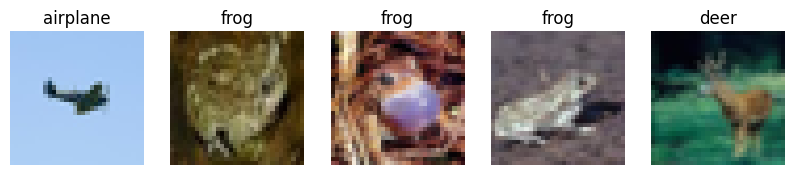

In [27]:
classes = train_dataset.classes

fig, axes = plt.subplots(1, 5, figsize=(10,3))

for i in range(5):
    img = images[i]
    img = img.permute(1,2,0)

    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis("off")

plt.show()

# Model

## Making the model

In [23]:
class CNN(nn.Module):
    def __init__(self, num_layers=2, num_filters=32):
        super().__init__()
        
        layers = []
        in_channels = 3
        
        for _ in range(num_layers):
            layers.append(nn.Conv2d(in_channels, num_filters, kernel_size=3, padding=1))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))
            in_channels = num_filters
        
        self.conv = nn.Sequential(*layers)
        
        conv_out_size = num_filters * (32 // (2 ** num_layers))**2
        self.fc = nn.Linear(conv_out_size, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x.view(x.size(0), -1))
        return x

In [24]:
def train_model(model, train_loader, test_loader, epochs=5, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")
    
    return model

## Small Experiment

In [29]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("CNN_CIFAR10")

modeldir = Path("cnn_models").resolve()
modeldir.mkdir(parents=True, exist_ok=True)

2026/03/15 14:10:11 INFO mlflow.tracking.fluent: Experiment with name 'CNN_CIFAR10' does not exist. Creating a new experiment.


In [28]:
from pathlib import Path

modeldir = Path("cnn_models").resolve()
modeldir.mkdir(parents=True, exist_ok=True)

In [30]:
mlflow.set_experiment("cnn_layers_filters")
model_configs = [
    {"name": "Exp1", "num_layers": 1, "num_filters": 32, "lr": 0.001},
    {"name": "Exp2", "num_layers": 2, "num_filters": 128, "lr": 0.001},
    {"name": "Exp3", "num_layers": 3, "num_filters": 64, "lr": 0.001},
    {"name": "Exp4", "num_layers": 2, "num_filters": 16, "lr": 0.001}
]

2026/03/15 14:10:23 INFO mlflow.tracking.fluent: Experiment with name 'cnn_layers_filters' does not exist. Creating a new experiment.


In [31]:
accuracy = Accuracy()

settings = TrainerSettings(
    epochs=5, 
    metrics=[accuracy],
    logdir=Path("gestures"),
    train_steps=len(train_subset),
    valid_steps=len(test_subset),
    reporttypes=[ReportTypes.TOML, ReportTypes.TENSORBOARD, ReportTypes.MLFLOW],
    scheduler_kwargs={"factor": 0.5, "patience": 5},
    earlystop_kwargs = {
        "save": False,
        "verbose": True,
        "patience": 5,
        "delta": 0.0,
    }
)
settings

device = "cuda" if torch.cuda.is_available() else "cpu"

2026-03-15 14:10:26.638 | INFO     | mltrainer.settings:check_path:60 - Created logdir c:\Users\Alex\Documents\GitHub\portfolio-example\4-hypertuning-ray\gestures


In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()

for trial, cfg in enumerate(model_configs):
    with mlflow.start_run():
        mlflow.set_tag("model", "cnn-cifar10")
        mlflow.set_tag("trial", trial)
        mlflow.set_tag("name", cfg["name"])
        mlflow.log_params(cfg)

        model = CNN(num_layers=cfg["num_layers"], num_filters=cfg["num_filters"]).to(device)

        trainer = Trainer(
            model=model,
            settings=settings,
            loss_fn=loss_fn,
            optimizer=optim.Adam,
            traindataloader=train_loader,
            validdataloader=test_loader,
            scheduler=optim.lr_scheduler.ReduceLROnPlateau,
            device=device,
        )
        trainer.loop()

        if not settings.earlystop_kwargs["save"]:
            from datetime import datetime
            tag = datetime.now().strftime("%Y%m%d-%H%M-")
            modelpath = modeldir / (tag + "model.pt")
            torch.save(model, modelpath)
            mlflow.log_artifact(modelpath)

## Full Training

In [34]:
conv_layers_options = [1, 2, 3, 4, 5]
conv_filters_options = [16, 32, 64, 128, 256]
learning_rate = 0.001

loss_fn = torch.nn.CrossEntropyLoss()

combinations = []
for l in conv_layers_options:
    for f in conv_filters_options:
        combinations.append({"num_layers": l, "num_filters": f})

for trial, cfg in enumerate(combinations):
    num_layers = cfg["num_layers"]
    num_filters = cfg["num_filters"]

    with mlflow.start_run():
        cfg_name = f"layers{num_layers}_filters{num_filters}"
        mlflow.set_tag("model", "cnn-cifar10")
        mlflow.set_tag("trial", trial)
        mlflow.set_tag("name", cfg_name)

        mlflow.log_params({
            "num_layers": num_layers,
            "num_filters": num_filters,
            "learning_rate": learning_rate
        })

        model = CNN(num_layers=num_layers, num_filters=num_filters).to(device)

        trainer = Trainer(
            model=model,
            settings=settings,
            loss_fn=loss_fn,
            optimizer=optim.Adam,
            traindataloader=train_loader,
            validdataloader=test_loader,
            scheduler=optim.lr_scheduler.ReduceLROnPlateau,
            device=device,
        )

        trainer.loop()

        tag = datetime.now().strftime("%Y%m%d-%H%M-")
        modelpath = modeldir / f"{tag}{cfg_name}_trial{trial}.pt"
        torch.save(model, modelpath)
        mlflow.log_artifact(modelpath)

        print(f"Run complete for trial {trial}: {cfg_name}")

2026-03-15 14:55:38.774 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to gestures\20260315-145538
2026-03-15 14:55:38.775 | INFO     | mltrainer.trainer:__init__:66 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|██████████| 5000/5000 [00:51<00:00, 97.10it/s] 
2026-03-15 14:56:39.019 | INFO     | mltrainer.trainer:report:215 - Epoch 0 train 0.7844 test 1.8215 metric ['0.5469']
100%|██████████| 5000/5000 [00:51<00:00, 97.06it/s]
2026-03-15 14:57:39.617 | INFO     | mltrainer.trainer:report:215 - Epoch 1 train 0.1519 test 2.7363 metric ['0.4844']
2026-03-15 14:57:39.618 | INFO     | mltrainer.trainer:__call__:258 - best loss: 1.8215, current loss 2.7363.Counter 1/5.
100%|██████████| 5000/5000 [00:51<00:00, 96.42it/s]
2026-03-15 14:58:40.628 | INFO     | mltrainer.trainer:report:215 - Epoch 2 train 0.0230 test 3.4847 metric ['0.5469']
2026-03-15 14:58:40.629 | INFO     | mltrainer.trainer:__call__:258 - best loss: 1.8215, current loss 

Run complete for trial 0: layers1_filters16


100%|██████████| 5000/5000 [00:53<00:00, 92.95it/s]
2026-03-15 15:01:43.373 | INFO     | mltrainer.trainer:report:215 - Epoch 0 train 0.5035 test 1.9348 metric ['0.5625']
100%|██████████| 5000/5000 [00:52<00:00, 94.49it/s]
2026-03-15 15:02:45.396 | INFO     | mltrainer.trainer:report:215 - Epoch 1 train 0.0330 test 2.8101 metric ['0.5000']
2026-03-15 15:02:45.397 | INFO     | mltrainer.trainer:__call__:258 - best loss: 1.9348, current loss 2.8101.Counter 1/5.
100%|██████████| 5000/5000 [00:55<00:00, 90.08it/s]
2026-03-15 15:03:49.815 | INFO     | mltrainer.trainer:report:215 - Epoch 2 train 0.0117 test 3.2316 metric ['0.5781']
2026-03-15 15:03:49.815 | INFO     | mltrainer.trainer:__call__:258 - best loss: 1.9348, current loss 3.2316.Counter 2/5.
100%|██████████| 5000/5000 [00:55<00:00, 90.41it/s]
2026-03-15 15:04:54.479 | INFO     | mltrainer.trainer:report:215 - Epoch 3 train 0.0059 test 3.2645 metric ['0.4844']
2026-03-15 15:04:54.480 | INFO     | mltrainer.trainer:__call__:258 - be

Run complete for trial 1: layers1_filters32


100%|██████████| 5000/5000 [00:57<00:00, 87.07it/s]
2026-03-15 15:07:06.661 | INFO     | mltrainer.trainer:report:215 - Epoch 0 train 0.3256 test 2.0652 metric ['0.5625']
100%|██████████| 5000/5000 [00:56<00:00, 88.24it/s]
2026-03-15 15:08:13.045 | INFO     | mltrainer.trainer:report:215 - Epoch 1 train 0.0157 test 2.6651 metric ['0.5312']
2026-03-15 15:08:13.046 | INFO     | mltrainer.trainer:__call__:258 - best loss: 2.0652, current loss 2.6651.Counter 1/5.
100%|██████████| 5000/5000 [00:56<00:00, 88.44it/s]
2026-03-15 15:09:19.216 | INFO     | mltrainer.trainer:report:215 - Epoch 2 train 0.0120 test 2.5446 metric ['0.4844']
2026-03-15 15:09:19.217 | INFO     | mltrainer.trainer:__call__:258 - best loss: 2.0652, current loss 2.5446.Counter 2/5.
100%|██████████| 5000/5000 [00:57<00:00, 86.95it/s]
2026-03-15 15:10:26.361 | INFO     | mltrainer.trainer:report:215 - Epoch 3 train 0.0101 test 2.5310 metric ['0.5312']
2026-03-15 15:10:26.362 | INFO     | mltrainer.trainer:__call__:258 - be

...

Run complete for trial 22: layers5_filters64


100%|██████████| 5000/5000 [01:07<00:00, 74.52it/s]
2026-03-15 17:18:01.353 | INFO     | mltrainer.trainer:report:215 - Epoch 0 train 0.3053 test 4.8199 metric ['0.5156']
100%|██████████| 5000/5000 [01:07<00:00, 74.27it/s]
2026-03-15 17:19:18.811 | INFO     | mltrainer.trainer:report:215 - Epoch 1 train 0.0429 test 5.0719 metric ['0.5000']
2026-03-15 17:19:18.811 | INFO     | mltrainer.trainer:__call__:258 - best loss: 4.8199, current loss 5.0719.Counter 1/5.
100%|██████████| 5000/5000 [01:07<00:00, 73.84it/s]
2026-03-15 17:20:36.510 | INFO     | mltrainer.trainer:report:215 - Epoch 2 train 0.0248 test 5.8330 metric ['0.5469']
2026-03-15 17:20:36.511 | INFO     | mltrainer.trainer:__call__:258 - best loss: 4.8199, current loss 5.8330.Counter 2/5.
100%|██████████| 5000/5000 [01:04<00:00, 77.03it/s]
2026-03-15 17:21:51.709 | INFO     | mltrainer.trainer:report:215 - Epoch 3 train 0.0009 test 7.1155 metric ['0.5156']
2026-03-15 17:21:51.710 | INFO     | mltrainer.trainer:__call__:258 - be

Run complete for trial 23: layers5_filters128


100%|██████████| 5000/5000 [01:41<00:00, 49.12it/s]
2026-03-15 17:25:04.057 | INFO     | mltrainer.trainer:report:215 - Epoch 0 train 0.2759 test 3.1165 metric ['0.6406']
100%|██████████| 5000/5000 [01:41<00:00, 49.08it/s]
2026-03-15 17:26:58.357 | INFO     | mltrainer.trainer:report:215 - Epoch 1 train 0.0744 test 3.5381 metric ['0.5781']
2026-03-15 17:26:58.358 | INFO     | mltrainer.trainer:__call__:258 - best loss: 3.1165, current loss 3.5381.Counter 1/5.
100%|██████████| 5000/5000 [01:41<00:00, 49.02it/s]
2026-03-15 17:28:52.635 | INFO     | mltrainer.trainer:report:215 - Epoch 2 train 0.0313 test 4.4067 metric ['0.4844']
2026-03-15 17:28:52.635 | INFO     | mltrainer.trainer:__call__:258 - best loss: 3.1165, current loss 4.4067.Counter 2/5.
100%|██████████| 5000/5000 [01:42<00:00, 48.69it/s]
2026-03-15 17:30:47.621 | INFO     | mltrainer.trainer:report:215 - Epoch 3 train 0.0108 test 4.6682 metric ['0.5938']
2026-03-15 17:30:47.621 | INFO     | mltrainer.trainer:__call__:258 - be

Run complete for trial 24: layers5_filters256
